**IMPORTS**

In [86]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import kagglehub
import random
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import Input

# Setting a seed to get the same accuracy results every time
seed_value = 33

os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


In [87]:
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


**LOADING DATA**

In [88]:
DATA_PATH = path

# Step 1: Load the Fashion MNIST Dataset from local
def load_fashion_mnist_data(path, kind='train'):
    """Load Fashion MNIST data from idx3-ubyte files."""
    if kind == 'train':
        labels_filename = 'train-labels-idx1-ubyte'
        images_filename = 'train-images-idx3-ubyte'
    else:
        labels_filename = 't10k-labels-idx1-ubyte'
        images_filename = 't10k-images-idx3-ubyte'

    labels_path = os.path.join(path, labels_filename)
    images_path = os.path.join(path, images_filename)

    with open(labels_path, 'rb') as lbpath:
        lbpath.seek(8)
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        imgpath.seek(16)
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 28, 28)

    return images, labels
try:
    # Load training data
    train_images, train_labels = load_fashion_mnist_data(DATA_PATH, kind='train')
    # Load test data
    test_images, test_labels = load_fashion_mnist_data(DATA_PATH, kind='t10k')
except FileNotFoundError as e:
    print(f"Error loading file: {e.filename}")
    print(f"Please make sure the data files are located in the '{DATA_PATH}' directory.")
    exit()

# Define class names for the labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


# Step 2: Preprocess the Data

train_images = train_images[..., None]
test_images = test_images[..., None]



**IMAGE RESIZING TO FIT RESNET INPUT SHAPE**

In [89]:
def create_resnet_dataset(images, labels, batch_size=32):
    def preprocess_image(image, label):
        image = tf.image.resize(image, [224, 224])
        image = tf.repeat(image, 3, axis=-1)
        image = preprocess_input(image)
        return image, label

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_resnet_dataset(
    train_images,
    train_labels,
    batch_size=256
)

test_dataset = create_resnet_dataset(
    test_images,
    test_labels,
    batch_size=256)

# 新段落

**MODEL**

In [90]:
# Step 4: Build the Neural Network Model
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
], name="rgb_augmentation")

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

inputs = Input(shape=(224, 224, 3))
x = augmenter(inputs)

x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Display a summary of the model's architecture
print("Model Summary:")
model.summary()

Model Summary:


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_40 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,146,442 (92.11 MB)

 Trainable params: 24,093,322 (91.91 MB)

 Non-trainable params: 53,120 (207.50 KB)

**TRAINING**

In [91]:
# Step 6: Train the Model
print("\nStarting model training...")
history = model.fit(
    train_dataset,
    epochs=10
)
print("Model training finished.")



Starting model training...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 165s 542ms/step - accuracy: 0.7141 - loss: 0.8549
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 127s 542ms/step - accuracy: 0.9061 - loss: 0.2798
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 127s 542ms/step - accuracy: 0.9239 - loss: 0.2297
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 127s 542ms/step - accuracy: 0.9331 - loss: 0.1945
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 127s 541ms/step - accuracy: 0.9408 - loss: 0.1743
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 127s 542ms/step - accuracy: 0.9466 - loss: 0.1577
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 128s 542ms/step - accuracy: 0.9522 - loss: 0.1407
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 127s 542ms/step - accuracy: 0.9546 - loss: 0.1282
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 127s 541ms/step - accuracy: 0.9606 - loss: 0.1144
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 128s 543ms/step - accuracy: 0.9620 - loss: 0.1134
Model training finished.


**PLOTTING HELPER FUNCS**

In [92]:
# Helper functions to visualize the predictions
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})",
               color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

**TESTING**


Evaluating model on test data...
40/40 - 7s - 177ms/step - accuracy: 0.9346 - loss: 0.1960

Test accuracy: 0.9346
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step

Visualizing a prediction...


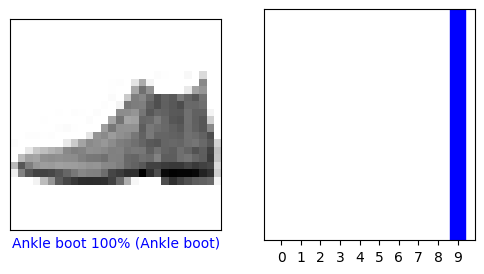


Plotting training history...


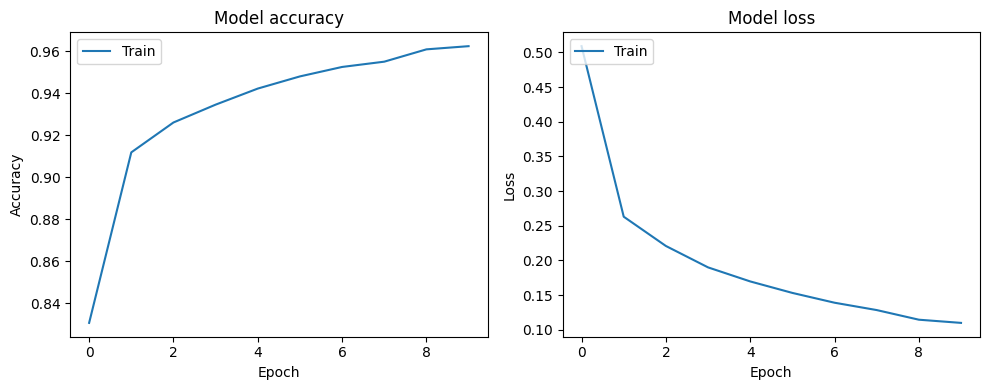

In [93]:
# Step 7: Evaluate the Model's Accuracy
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(test_dataset, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

# Step 8: Make Predictions
predictions = model.predict(test_dataset)


# Let's visualize the prediction for the first image
print("\nVisualizing a prediction...")
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

# Plot training & validation accuracy values
print("\nPlotting training history...")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

plt.tight_layout()
plt.show()